# Facility-Level Heat Index Results — Exploratory Plots

Exploratory plots over `outputs/month2_heat/facility_heat_indices.csv`, the
per-facility table produced by `scripts/extract_facility_heat_indices.py`
(109/109 Oregon data centers).

## Scope
- Heat only (CDD, Tmax threshold-days >35C, heatwave events >=3 consecutive
  days >35C), sampled at each facility's own lon/lat from the rasters
  `scripts/run_heat_processing.py` already generated.
- Historical (1950-1979) vs. SSP585 (2070-2099), single LOCA2 GCM/member
  (ACCESS-CM2, r1i1p1f1) — not an ensemble; see `run_heat_processing.py`
  docstring.
- Elevation-adjusted thresholds are **not** in this table (no DEM in the repo
  yet) — see `extract_facility_heat_indices.py`'s assumptions log.

This notebook only reads the CSV and existing rasters/boundary data; it does
not recompute anything. Rerun `scripts/extract_facility_heat_indices.py`
first if the CSV is missing or stale.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

ROOT = Path('/home/server/pi/homes/queenl/projects/climate-risk-dc')
OUT = ROOT / 'outputs' / 'month2_heat'
FACILITY_CSV = OUT / 'facility_heat_indices.csv'
WBD_GDB = ROOT / 'data' / 'watershed_boundaries' / 'WBD_National_GDB.gdb'


## Palette and chart style

Fixed roles from the project's validated reference palette (light mode):
one categorical blue for single-series comparisons, a one-hue blue ramp for
sequential/magnitude encoding, and muted ink/gridline tokens so text never
borrows the series color. See the `dataviz` skill's `references/palette.md`
for the full set and the colorblind-safety validation behind it.


In [2]:
# Reference palette (light mode) -- see dataviz skill references/palette.md
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
AXIS_LINE = '#c3c2b7'
SERIES_BLUE = '#2a78d6'      # categorical slot 1 -- single-series marks
SERIES_ORANGE = '#eb6834'    # categorical slot 2 -- used only where a 2nd series is real

# Sequential one-hue blue ramp, light (near-zero) -> dark (high magnitude)
SEQUENTIAL_BLUE_STEPS = [
    '#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7',
    '#3987e5', '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b',
]
SEQUENTIAL_BLUE_CMAP = LinearSegmentedColormap.from_list('sequential_blue', SEQUENTIAL_BLUE_STEPS)

plt.rcParams.update({
    'figure.dpi': 140,
    'axes.edgecolor': AXIS_LINE,
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlecolor': INK_PRIMARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'grid.color': GRIDLINE,
    'axes.grid': True,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})


## Load facility results

In [3]:
if not FACILITY_CSV.exists():
    raise FileNotFoundError(
        f'{FACILITY_CSV} not found -- run scripts/extract_facility_heat_indices.py first.'
    )

facilities = pd.read_csv(FACILITY_CSV)
facilities['facility_label'] = facilities['facility_name'].fillna(
    'Unnamed (ID ' + facilities['facility_id'].astype(str) + ')'
)

print(f'{len(facilities)} facilities loaded')
neg_days = int((facilities['tmax_threshold_days_delta'] < 0).sum())
neg_events = int((facilities['heatwave_events_delta'] < 0).sum())
print(f'Sanity: {neg_days} negative tmax_threshold_days_delta, {neg_events} negative heatwave_events_delta (expect 0 under SSP585)')
facilities.head()


109 facilities loaded
Sanity: 0 negative tmax_threshold_days_delta, 0 negative heatwave_events_delta (expect 0 under SSP585)


,facility_id,facility_name,facility_lon,facility_lat,cdd_historical_1950_1979,tmax_threshold_days_historical_1950_1979,heatwave_events_historical_1950_1979,cdd_ssp585_2070_2099,tmax_threshold_days_ssp585_2070_2099,heatwave_events_ssp585_2070_2099,tmax_threshold_days_delta,heatwave_events_delta,facility_label
0,19988712,Meta Prineville Datacenter,-120.886382,44.298443,60.775326,4.600000,0.633333,830.032715,76.720001,5.32,72.120001,4.686667,Meta Prineville Datacenter
1,19993392,Apple Prineville Datacenter,-120.865883,44.284558,69.258736,6.433333,0.833333,889.870789,82.120003,5.56,75.686669,4.726667,Apple Prineville Datacenter
2,52059176,NTT RagingWire Data Center,-122.937393,45.549584,162.152985,3.233333,0.633333,919.863464,44.919998,6.00,41.686665,5.366667,NTT RagingWire Data Center
3,231769626,Google Data Center The Dalles Oregon,-121.201302,45.632048,338.070679,13.000000,2.166667,1386.147339,84.559998,6.80,71.559998,4.633333,Google Data Center The Dalles Oregon
4,321385147,NaN,-120.887261,44.295883,60.775326,4.600000,0.633333,830.032715,76.720001,5.32,72.120001,4.686667,Unnamed (ID 321385147)


## Historical vs. future, per facility

One point per facility, historical value on x, SSP585-future value on y, for
each index. A single series (facility) plotted against itself across two
time windows, so one categorical color and a 1:1 reference line rather than
a legend -- points above the dashed line got hotter under SSP585.


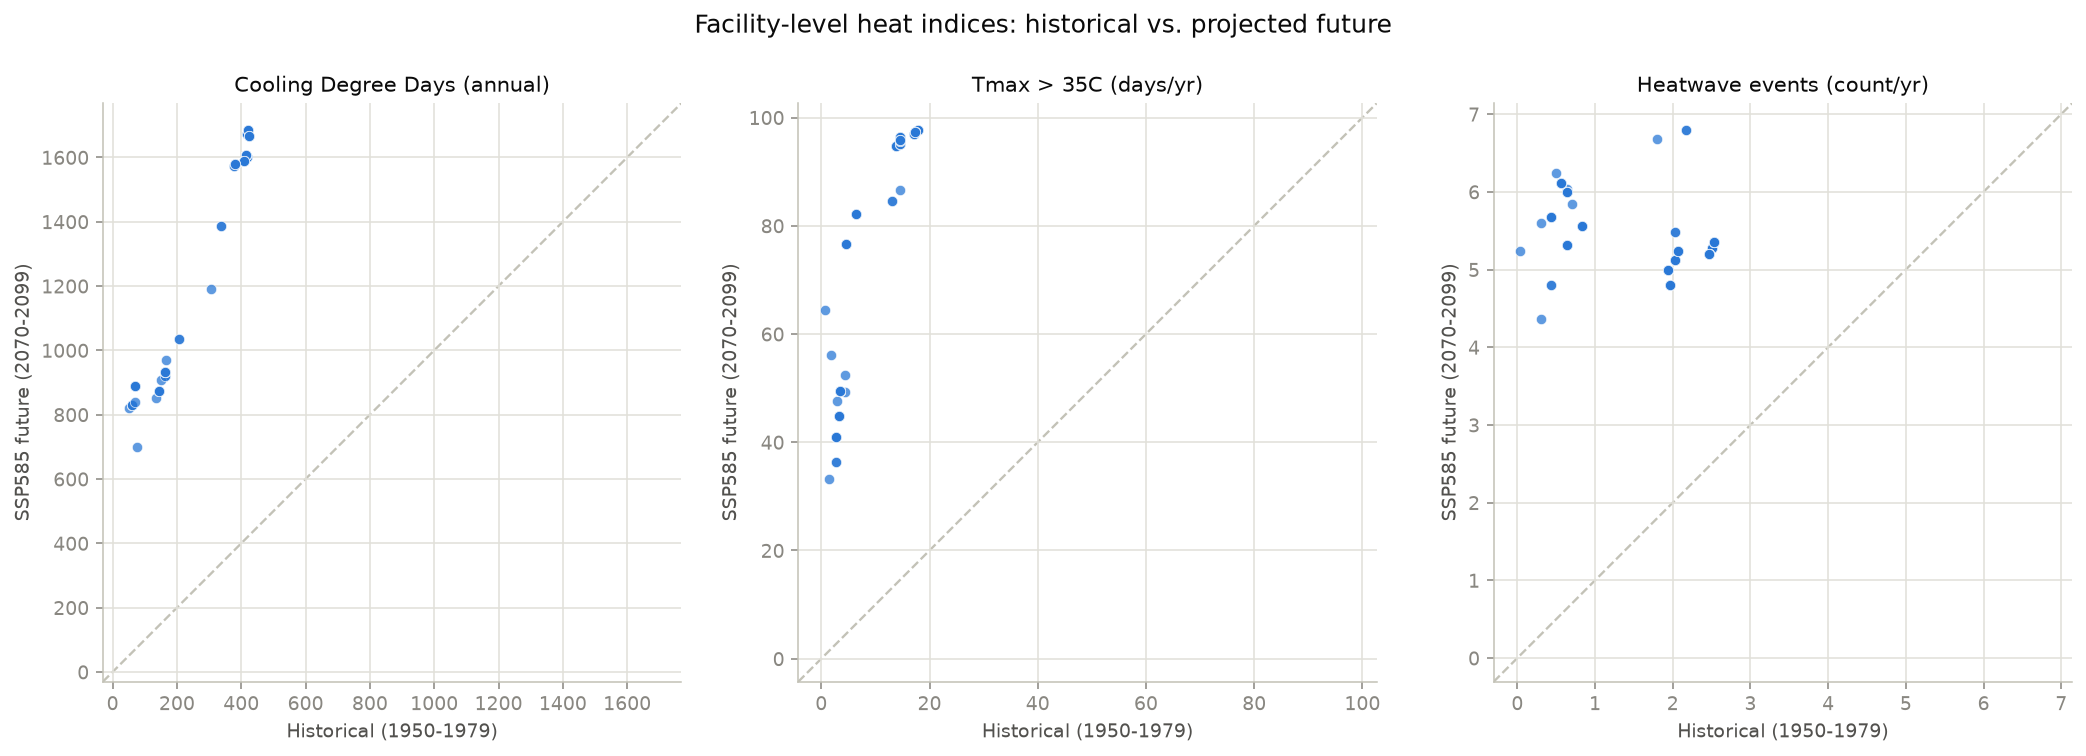

In [4]:
index_panels = [
    ('cdd', 'cdd_historical_1950_1979', 'cdd_ssp585_2070_2099', 'Cooling Degree Days (annual)'),
    ('tmax_days', 'tmax_threshold_days_historical_1950_1979', 'tmax_threshold_days_ssp585_2070_2099', 'Tmax > 35C (days/yr)'),
    ('heatwave', 'heatwave_events_historical_1950_1979', 'heatwave_events_ssp585_2070_2099', 'Heatwave events (count/yr)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (_, hist_col, fut_col, title) in zip(axes, index_panels):
    x = facilities[hist_col].to_numpy()
    y = facilities[fut_col].to_numpy()
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    pad = (hi - lo) * 0.05
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', linewidth=1.2, color=AXIS_LINE, zorder=1)
    ax.scatter(x, y, s=28, color=SERIES_BLUE, alpha=0.75, edgecolor='white', linewidth=0.4, zorder=2)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel('Historical (1950-1979)')
    ax.set_ylabel('SSP585 future (2070-2099)')
    ax.set_title(title, color=INK_PRIMARY, fontsize=11)
    ax.set_aspect('equal', adjustable='box')

fig.suptitle('Facility-level heat indices: historical vs. projected future', y=1.03, fontsize=13, color=INK_PRIMARY)
fig.tight_layout()
plt.show()


## Distribution of projected change (delta = SSP585 future − historical)

Single-hue histograms (magnitude, not polarity — deltas are expected
non-negative per the sanity check above, so a diverging scale isn't
appropriate here).


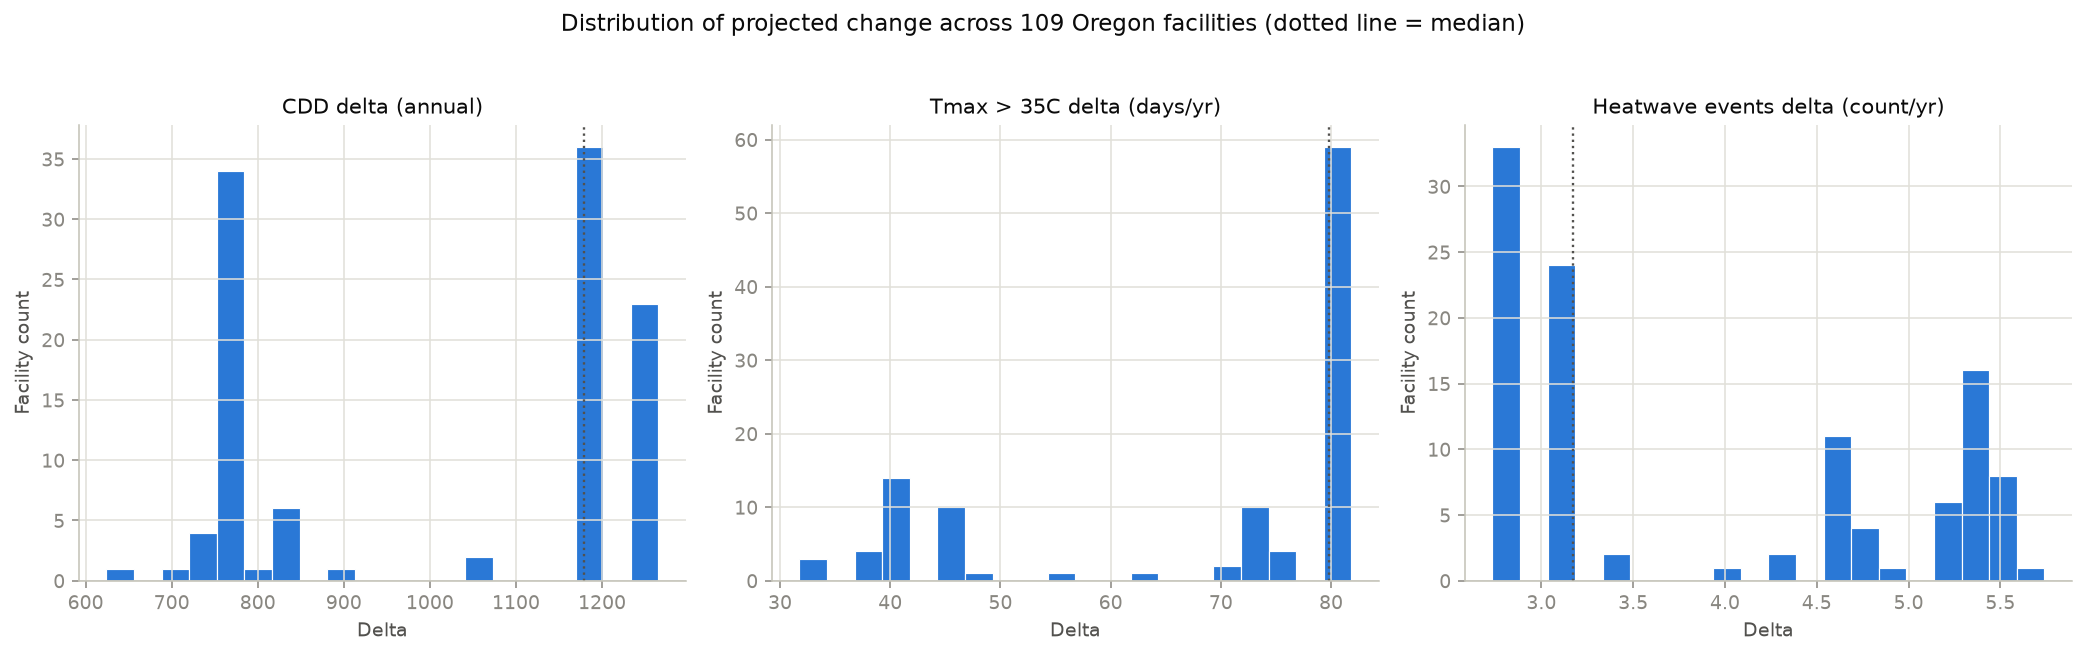

In [5]:
delta_panels = [
    ('cdd_ssp585_2070_2099', 'cdd_historical_1950_1979', 'CDD delta (annual)'),
    ('tmax_threshold_days_delta', None, 'Tmax > 35C delta (days/yr)'),
    ('heatwave_events_delta', None, 'Heatwave events delta (count/yr)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (fut_col, hist_col, title) in zip(axes, delta_panels):
    values = (facilities[fut_col] - facilities[hist_col]) if hist_col else facilities[fut_col]
    ax.hist(values, bins=20, color=SEQUENTIAL_BLUE_STEPS[7], edgecolor='white', linewidth=0.6)
    ax.axvline(values.median(), color=INK_SECONDARY, linestyle=':', linewidth=1.2)
    ax.set_title(title, color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel('Delta')
    ax.set_ylabel('Facility count')

fig.suptitle('Distribution of projected change across 109 Oregon facilities (dotted line = median)', y=1.03, fontsize=12, color=INK_PRIMARY)
fig.tight_layout()
plt.show()


## Facilities with the largest projected increase

Top 15 by heatwave-event delta. Ordered ranking, single hue (magnitude, not
identity), with direct end-labels since there are only 15 bars.


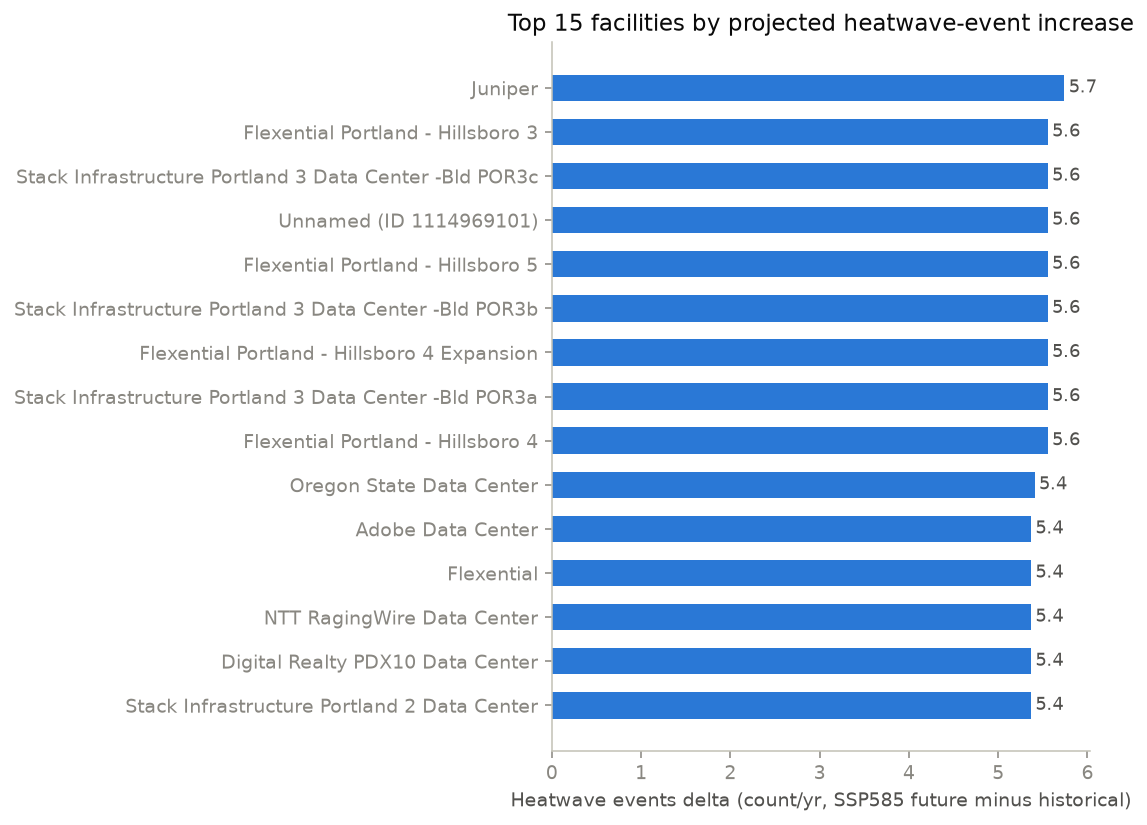

In [6]:
top15 = facilities.nlargest(15, 'heatwave_events_delta').sort_values('heatwave_events_delta')

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top15['facility_label'], top15['heatwave_events_delta'], color=SERIES_BLUE, height=0.6)
for bar, value in zip(bars, top15['heatwave_events_delta']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f'{value:.1f}',
            va='center', ha='left', fontsize=9, color=INK_SECONDARY)

ax.set_xlabel('Heatwave events delta (count/yr, SSP585 future minus historical)')
ax.set_title('Top 15 facilities by projected heatwave-event increase', color=INK_PRIMARY, fontsize=12)
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()


## Geographic pattern

Facility locations colored by Tmax-threshold-day delta (sequential blue
ramp = magnitude; a colorbar substitutes for a legend since color here is
continuous, not categorical). Oregon HUC8 outline for context, dissolved
from the same watershed boundary file the dependency-table notebooks use.


ERROR 1: PROJ: proj_create_from_database: Open of /home/server/pi/homes/queenl/.conda/envs/climate-risk/share/proj failed


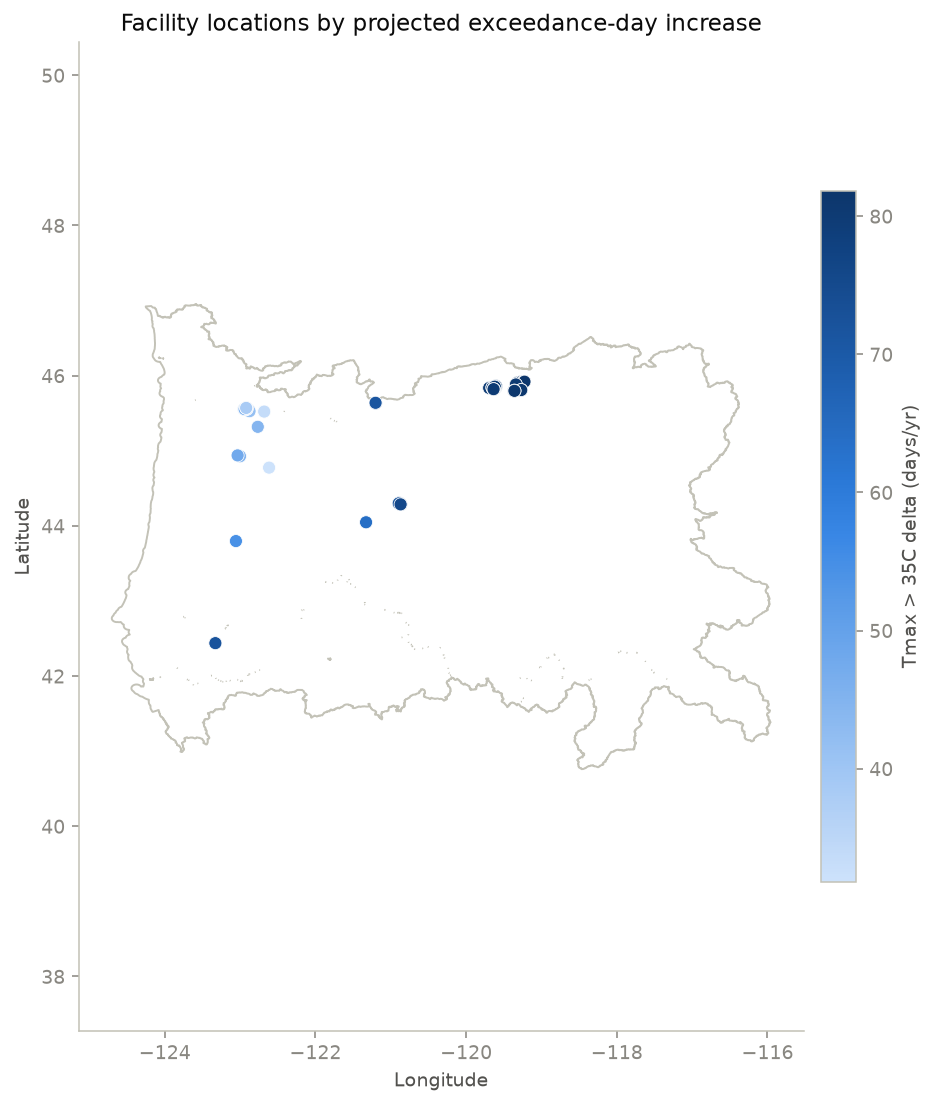

In [7]:
try:
    wbd = gpd.read_file(WBD_GDB, layer='WBDHU8')
    if wbd.crs is None:
        wbd = wbd.set_crs('EPSG:4326')
    wbd = wbd.to_crs('EPSG:4326')
    if 'states' in wbd.columns:
        wbd = wbd[wbd['states'].fillna('').str.contains('OR')]
    oregon_outline = gpd.GeoDataFrame(geometry=[wbd.union_all()], crs='EPSG:4326')
except Exception as exc:
    oregon_outline = None
    print(f'Skipping Oregon outline (boundary data unavailable: {exc})')

fig, ax = plt.subplots(figsize=(7, 8))
if oregon_outline is not None:
    oregon_outline.boundary.plot(ax=ax, color=AXIS_LINE, linewidth=1.0, zorder=1)

sc = ax.scatter(
    facilities['facility_lon'], facilities['facility_lat'],
    c=facilities['tmax_threshold_days_delta'], cmap=SEQUENTIAL_BLUE_CMAP,
    s=45, edgecolor='white', linewidth=0.4, zorder=2,
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Tmax > 35C delta (days/yr)', color=INK_SECONDARY)
cbar.ax.tick_params(color=INK_MUTED, labelcolor=INK_MUTED)

ax.set_title('Facility locations by projected exceedance-day increase', color=INK_PRIMARY, fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal', adjustable='datalim')
ax.grid(False)
fig.tight_layout()
plt.show()


## Caveats

- Single-GCM/member (ACCESS-CM2, r1i1p1f1) — not an ensemble spread; treat
  magnitudes as one plausible trajectory, not a confidence interval.
- No elevation adjustment applied yet (no DEM in the repo) — high-elevation
  facilities' thresholds are not corrected for the ISA lapse rate.
- Flat 35C exceedance threshold for all facilities (ASHRAE Class A2 upper
  bound), not facility-specific equipment ratings.
- `facility_label` falls back to `Unnamed (ID ...)` for the handful of
  Prineville/PDX parcels with a null name in the source atlas.
